In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def stitch_images(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    sift = cv2.SIFT_create()
    
    keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)
    
    bf = cv2.BFMatcher()
    
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)
    
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
    
    src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    stitched = cv2.warpPerspective(img1, H, (w1 + w2, h1))
    stitched[0:h2, 0:w2] = img2
    
    return stitched, H

In [23]:
img1 = cv2.imread('k1.jpg')
img2 = cv2.imread('k2.jpg')

In [24]:
result, homography_matrix = stitch_images(img1, img2)

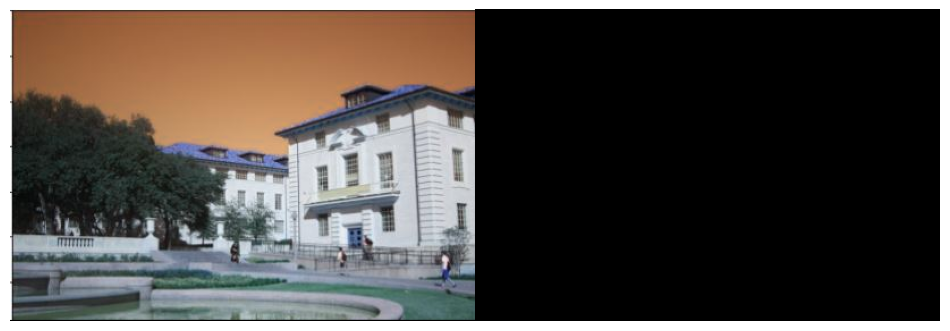

In [28]:
plt.figure(figsize=(12, 12))
plt.imshow(result)
plt.axis('off')
plt.show()